# Lab 3: Neural Networks: Feedforward Networks and the Training Process

**Duration:** 1 week [21 Jul - 28 Jul, 2026]
**Due Date:** 28th July, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** Eyram Fenu
**Student ID:** 31122028

---

### Objective

This lab bridges the gap between classical ML and deep learning. Instead of calling
`.fit()` and trusting scikit-learn, you will **open the black box**: build a neural network
from a single neuron upward, watch gradient descent learn, and then train a full
**feedforward network (MLP) in PyTorch** on a dataset you already know from Lab 2.

By the end you should be able to explain, and demonstrate with your own plots, what each
of these really does: **weights, activation functions, loss, gradients, learning rate,
epochs, batches, and overfitting**.

We deliberately stay on **tabular data** this week. Images and CNNs come in the next lab.

---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-3` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_3.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas matplotlib scikit-learn torch`.
5. Commit and push after completing **each Part** below — we will check your commit history.
   A single "final commit" with everything at once loses marks.

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


---
# Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Before touching PyTorch's automation, you will build the moving parts **yourself with NumPy**
on a toy problem, so that nothing later in the lab is magic.

The toy problem: learn the function `y = sin(x)` on the interval `[-3, 3]` from 100 noisy
samples. It is 1-dimensional, so we can *plot everything* — the data, the model's prediction,
and the loss going down.

### Part 1.1 — A single neuron is just a line
A neuron computes `y_hat = w * x + b`. Fit it to the sine data with **manual gradient descent**.

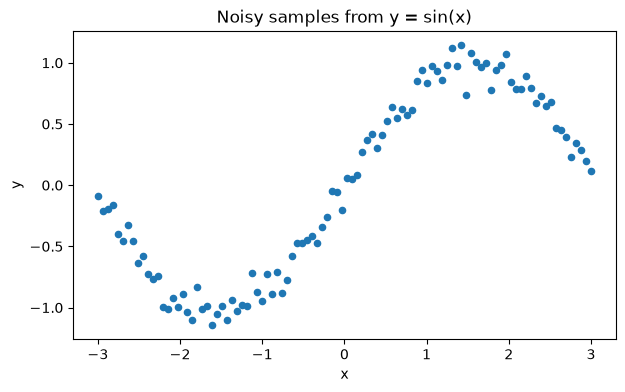

Final weight: 0.3390
Final bias: -0.0104
Final MSE: 0.1955


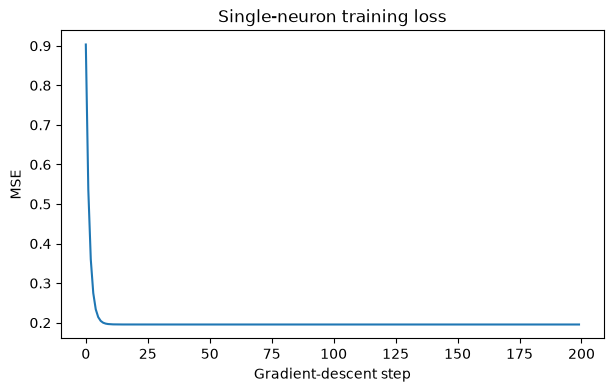

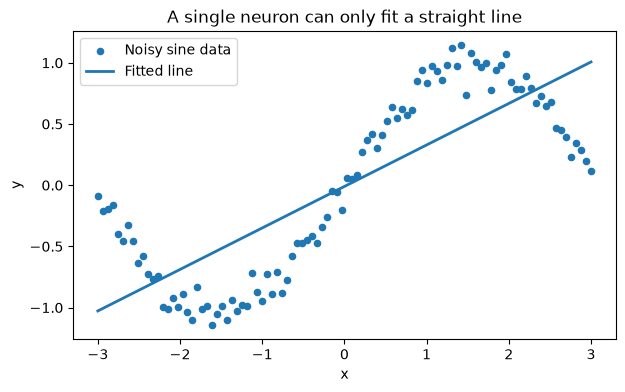

In [2]:
# Generate the toy data
x = np.linspace(-3, 3, 100).reshape(-1, 1)
y = (np.sin(x) + np.random.normal(0, 0.1, size=x.shape)).reshape(-1, 1)

plt.figure(figsize=(7, 4))
plt.scatter(x.ravel(), y.ravel(), s=20)
plt.title("Noisy samples from y = sin(x)")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

# Initialise the parameters of one neuron to small random values
w = float(np.random.randn() * 0.1)
b = float(np.random.randn() * 0.1)
lr = 0.05
losses_single = []

# Manual gradient descent
for step in range(200):
    y_hat = w * x + b
    error = y_hat - y
    loss = np.mean(error ** 2)

    dw = np.mean(2 * error * x)
    db = np.mean(2 * error)

    w -= lr * dw
    b -= lr * db

    losses_single.append(float(loss))

print(f"Final weight: {w:.4f}")
print(f"Final bias: {b:.4f}")
print(f"Final MSE: {losses_single[-1]:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(losses_single)
plt.title("Single-neuron training loss")
plt.xlabel("Gradient-descent step")
plt.ylabel("MSE")
plt.show()

plt.figure(figsize=(7, 4))
plt.scatter(x.ravel(), y.ravel(), s=20, label="Noisy sine data")
plt.plot(x.ravel(), (w * x + b).ravel(), linewidth=2, label="Fitted line")
plt.title("A single neuron can only fit a straight line")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

**Student Reasoning — The single neuron**
*1. Derive `dLoss/dw` on paper and include a photo or the LaTeX in this cell — does it match
the code?*
*2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting,
and WHY can a single neuron never fit a sine wave, no matter how long you train?*

> **Answer:** ### 1.

The prediction made by a single neuron is

$$
\hat{y}=wx+b.
$$

The Mean Squared Error (MSE) loss is

$$
L=\frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i-y_i)^2.
$$

Using the chain rule,

$$
\frac{\partial L}{\partial w}
=
\frac{1}{n}
\sum_{i=1}^{n}
2(\hat{y}_i-y_i)
\frac{\partial \hat{y}_i}{\partial w}.
$$

Since

$$
\frac{\partial \hat{y}}{\partial w}=x,
$$

we obtain

$$
\boxed{
\frac{\partial L}{\partial w}
=
\frac{2}{n}
\sum_{i=1}^{n}
(\hat{y}_i-y_i)x_i
}
$$

Similarly,

$$
\boxed{
\frac{\partial L}{\partial b}
=
\frac{2}{n}
\sum_{i=1}^{n}
(\hat{y}_i-y_i)
}
$$

This matches the implementation:

```python
dw = np.mean(2 * error * x)
db = np.mean(2 * error)
```

because `error = y_hat - y`.

###2.
The model is **underfitting** because it is too simple to capture the underlying pattern in the data.

A single neuron computes the prediction

$$
\hat{y}=wx+b,
$$

which is a **linear function**. Regardless of how the values of \(w\) and \(b\) change during training, the output will always be a straight line.

However, the target function is

$$
y=\sin(x),
$$

which is **nonlinear** and oscillates continuously. Since a straight line cannot represent these oscillations, the model lacks the capacity to learn the true relationship between the input and output.

Although gradient descent successfully minimizes the loss, it can only find the **best-fitting straight line** rather than accurately modelling the sine curve. This is why the model underfits the data.
### 3.
Training for significantly more iterations would **not** allow the model to fit the sine wave. Instead, the parameters \(w\) and \(b\) would eventually converge to values that produce the lowest possible loss for a straight line.

Once convergence is reached, the gradients become very small,

$$
\frac{\partial L}{\partial w}\approx0
\qquad\text{and}\qquad
\frac{\partial L}{\partial b}\approx0,
$$

meaning that further gradient descent updates produce almost no change in the parameters.

Consequently, the training loss would plateau, and the fitted line would remain essentially unchanged. Improving the fit requires a **more expressive model**, such as a neural network with one or more hidden layers and nonlinear activation functions, rather than simply training a single neuron for more iterations.



### Part 1.2 — Hidden layers and activations: why depth helps
Now build a tiny network **by hand**: 1 input -> a hidden layer of 8 neurons with `tanh` ->
1 output. Still NumPy, still manual gradients.

Final MSE with tanh: 0.0150
Final MSE without tanh: 0.1955


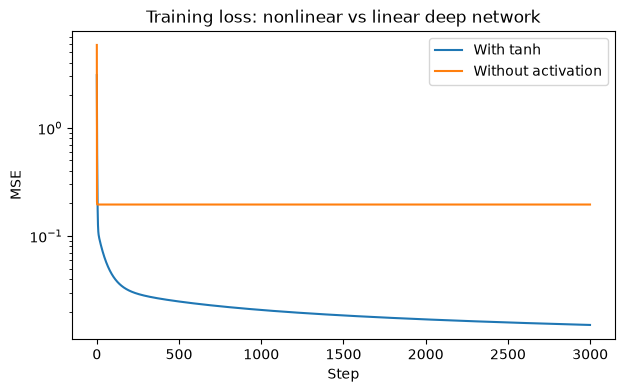

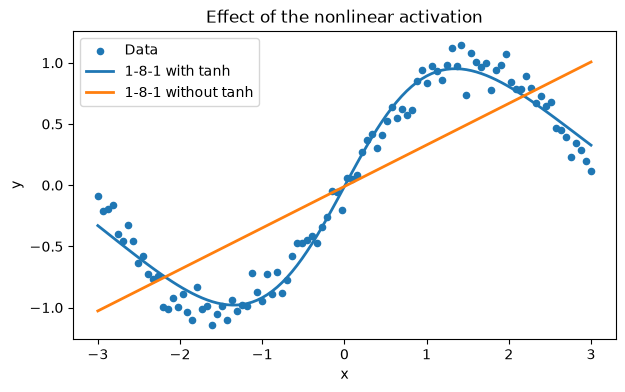

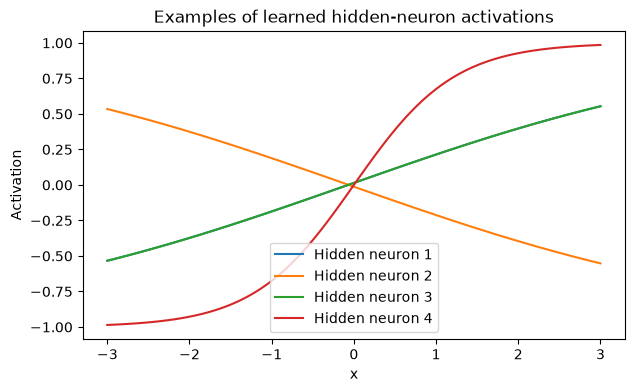

In [3]:
# Reset the seed so this experiment is reproducible
np.random.seed(RANDOM_STATE)

# Initialise parameters for a 1 -> 8 -> 1 network
W1 = np.random.randn(1, 8) * 0.5
b1 = np.zeros(8)
W2 = np.random.randn(8, 1) * 0.5
b2 = np.zeros(1)

lr = 0.05
losses_tanh = []

for step in range(3000):
    # Forward pass
    z1 = x @ W1 + b1
    h = np.tanh(z1)
    y_hat = h @ W2 + b2
    loss = np.mean((y_hat - y) ** 2)
    losses_tanh.append(float(loss))

    # Backward pass
    d_yhat = 2 * (y_hat - y) / len(y)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)
    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)

    # Parameter update
    W2 -= lr * dW2
    b2 -= lr * db2
    W1 -= lr * dW1
    b1 -= lr * db1

final_tanh_prediction = np.tanh(x @ W1 + b1) @ W2 + b2

# Repeat with the activation removed: h = z1
np.random.seed(RANDOM_STATE)
W1_linear = np.random.randn(1, 8) * 0.5
b1_linear = np.zeros(8)
W2_linear = np.random.randn(8, 1) * 0.5
b2_linear = np.zeros(1)
losses_linear_deep = []

for step in range(3000):
    z1_linear = x @ W1_linear + b1_linear
    h_linear = z1_linear
    y_hat_linear = h_linear @ W2_linear + b2_linear
    loss_linear = np.mean((y_hat_linear - y) ** 2)
    losses_linear_deep.append(float(loss_linear))

    d_yhat = 2 * (y_hat_linear - y) / len(y)
    dW2 = h_linear.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh = d_yhat @ W2_linear.T
    dz1 = dh
    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)

    W2_linear -= lr * dW2
    b2_linear -= lr * db2
    W1_linear -= lr * dW1
    b1_linear -= lr * db1

final_linear_prediction = (x @ W1_linear + b1_linear) @ W2_linear + b2_linear

print(f"Final MSE with tanh: {losses_tanh[-1]:.4f}")
print(f"Final MSE without tanh: {losses_linear_deep[-1]:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(losses_tanh, label="With tanh")
plt.plot(losses_linear_deep, label="Without activation")
plt.title("Training loss: nonlinear vs linear deep network")
plt.xlabel("Step")
plt.ylabel("MSE")
plt.yscale("log")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.scatter(x.ravel(), y.ravel(), s=20, label="Data")
plt.plot(x.ravel(), final_tanh_prediction.ravel(), linewidth=2, label="1-8-1 with tanh")
plt.plot(x.ravel(), final_linear_prediction.ravel(), linewidth=2, label="1-8-1 without tanh")
plt.title("Effect of the nonlinear activation")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

# Plot a few hidden-neuron activations
h_final = np.tanh(x @ W1 + b1)

plt.figure(figsize=(7, 4))
for neuron_index in range(4):
    plt.plot(x.ravel(), h_final[:, neuron_index],
             label=f"Hidden neuron {neuron_index + 1}")

plt.title("Examples of learned hidden-neuron activations")
plt.xlabel("x")
plt.ylabel("Activation")
plt.legend()
plt.show()

**Student Reasoning — Depth and activations**
*1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1.
Explain mathematically why a stack of linear layers collapses into one linear layer.*
*2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few
columns of `h` against `x`.)*
*3. This is exactly what `loss.backward()` will automate in Section 2. In one sentence, what
is backpropagation?*

> **Answer:** ### 1.

Without the `tanh` activation, the hidden layer computes

$$
h = XW_1 + b_1.
$$

The output layer then computes

$$
\hat{y} = hW_2 + b_2.
$$

Substituting the first equation into the second gives

$$
\hat{y} = (XW_1 + b_1)W_2 + b_2.
$$

Expanding this expression gives

$$
\hat{y} = XW_1W_2 + b_1W_2 + b_2.
$$

Let

$$
W = W_1W_2
$$

and

$$
b = b_1W_2 + b_2.
$$

The network can therefore be rewritten as

$$
\hat{y} = XW + b.
$$

This is still a single linear model. Therefore, stacking linear layers without a nonlinear activation does not increase the expressive power of the network. This explains why the network without `tanh` produced a straight-line fit and obtained an MSE of **0.1955**, similar to the single neuron in Part 1.1.

### 2. 

The 8 hidden neurons learned different nonlinear transformations of the input through

$$
h_j = \tanh(xw_j + b_j),
$$

where \(h_j\) is the activation produced by hidden neuron \(j\).

From the hidden-neuron activation plot, some neurons learned increasing curves, some learned decreasing curves, and others learned sharper S-shaped transitions. Each neuron therefore captured a different feature or region of the input pattern.

The output layer combined the activations of all 8 neurons using

$$
\hat{y} = hW_2 + b_2.
$$

By combining these different nonlinear features, the network was able to form a curved prediction that closely followed the sine-wave data. This resulted in a much lower final MSE of **0.0150**.

### 3. 

Backpropagation is the process of applying the chain rule from the output layer backwards through the network to calculate the gradient of the loss with respect to every weight and bias.

### Part 1.3 — The learning rate: too cold, too hot, just right
The single most important hyperparameter. See its three regimes with your own eyes.

c:\Users\eyram\lab-3\lab-3\.venv\Lib\site-packages\matplotlib\scale.py:375: RuntimeWarning: overflow encountered in exp
  return np.exp(values * np.log(self.base))


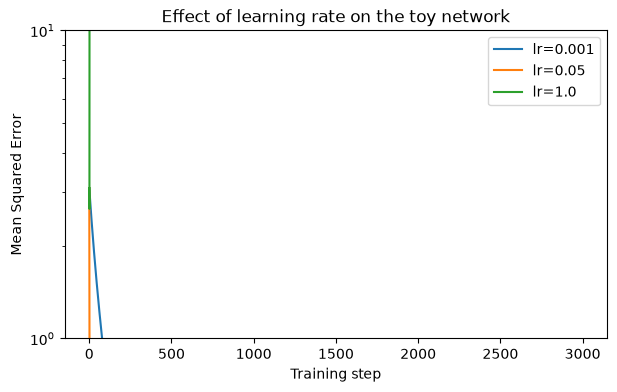

In [4]:
def train_toy(lr, steps=3000):
    """Train the manual 1 -> 8 -> 1 tanh network and return its losses."""
    np.random.seed(RANDOM_STATE)
    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.zeros(8)
    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.zeros(1)
    losses = []

    with np.errstate(over="ignore", invalid="ignore"):
        for _ in range(steps):
            z1 = x @ W1 + b1
            h = np.tanh(z1)
            y_hat = h @ W2 + b2
            loss = np.mean((y_hat - y) ** 2)
            losses.append(float(loss))

            if not np.isfinite(loss):
                break

            d_yhat = 2 * (y_hat - y) / len(y)
            dW2 = h.T @ d_yhat
            db2 = d_yhat.sum(axis=0)
            dh = d_yhat @ W2.T
            dz1 = dh * (1 - np.tanh(z1) ** 2)
            dW1 = x.T @ dz1
            db1 = dz1.sum(axis=0)

            W2 -= lr * dW2
            b2 -= lr * db2
            W1 -= lr * dW1
            b1 -= lr * db1

    return losses

learning_rates = [0.001, 0.05, 1.0]

toy_lr_results = {
    lr: train_toy(lr)
    for lr in learning_rates
}

plt.figure(figsize=(7, 4))

for lr, losses in toy_lr_results.items():
    plt.plot(losses, label=f"lr={lr}")

plt.title("Effect of learning rate on the toy network")
plt.xlabel("Training step")
plt.ylabel("Mean Squared Error")
plt.yscale("log")
plt.legend()
plt.show()

**Student Reasoning — Learning rate**
*Describe what each of the three curves shows. Why does a too-large learning rate make the
loss explode or oscillate instead of just "learning faster"?*

> **Answer:** 
- **Learning rate = 0.001 (blue):** The loss decreases steadily but very slowly. The updates are small, making training stable but requiring many iterations to reach a good solution.

- **Learning rate = 0.05 (orange):** The loss drops much more quickly and converges smoothly. This learning rate is large enough to speed up training while remaining stable, making it the best choice among the three.

- **Learning rate = 1.0 (green):** The loss immediately becomes unstable and diverges. The parameter updates are so large that they overshoot the minimum of the loss function, causing the optimization process to oscillate or explode instead of converging.

A learning rate that is too large does not make learning faster because gradient descent assumes small steps toward the minimum. When the step size is excessively large, each update jumps past the optimum, and the errors become larger rather than smaller. Consequently, the loss oscillates or increases rapidly instead of converging.

---
# Section 2 — A Real Feedforward Network in PyTorch

Now we let PyTorch do the bookkeeping (`autograd`, optimizers, batching) and apply the ideas
from Section 1 to a real problem — one you already know:

## Predicting obesity level (`NObeyesdad`) — the Lab 2 dataset

Same data, same 7 classes, same preprocessing ideas — but this time the model is a neural
network you design and train yourself. At the end you will compare it head-to-head with your
Lab 2 classical models.

### Part 2.1 — Preprocess and split (recycled from Lab 2)
Reuse your Lab 2 pipeline: encode categoricals, scale numerics, stratified three-way split.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from torch.utils.data import TensorDataset, DataLoader

# Same dataset used in Lab 2
OBESITY_URL = (
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/"
    "GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
)

df = pd.read_csv(OBESITY_URL)

print("Dataset shape:", df.shape)
display(df.head())

# Split features and target
X = df.drop(columns=["NObeyesdad"])
y = df["NObeyesdad"]

# Encode target labels to integers (0–6)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
class_names = label_encoder.classes_

# Categorical and numerical columns
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numeric_features = X.select_dtypes(exclude=["object"]).columns.tolist()

# Preprocessing pipeline (same style as Lab 2)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

# 60/20/20 stratified split
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    stratify=y,
    random_state=RANDOM_STATE,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE,
)

# Fit ONLY on training data
X_train = preprocessor.fit_transform(X_train)
X_val = preprocessor.transform(X_val)
X_test = preprocessor.transform(X_test)

# Convert sparse matrices to dense arrays if needed
if hasattr(X_train, "toarray"):
    X_train = X_train.toarray()
    X_val = X_val.toarray()
    X_test = X_test.toarray()

# Convert to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Create datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

input_dim = X_train_tensor.shape[1]
n_classes = len(class_names)

print(f"Input dimension: {input_dim}")
print(f"Number of classes: {n_classes}")
print("Classes:", class_names)
print(
    f"Train: {len(train_dataset)}, "
    f"Validation: {len(val_dataset)}, "
    f"Test: {len(test_dataset)}"
)

Dataset shape: (2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


Input dimension: 31
Number of classes: 7
Classes: ['Insufficient_Weight' 'Normal_Weight' 'Obesity_Type_I' 'Obesity_Type_II'
 'Obesity_Type_III' 'Overweight_Level_I' 'Overweight_Level_II']
Train: 1266, Validation: 422, Test: 423


C:\Users\eyram\AppData\Local\Temp\ipykernel_16952\414964819.py:28: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns.tolist()


### Student Reasoning

**1. Why does `CrossEntropyLoss` need integer class labels rather than one-hot vectors in PyTorch?**

`CrossEntropyLoss` expects each training example to belong to exactly one class and therefore requires the target labels as integer class indices (0–6). Internally, it combines `LogSoftmax` and `Negative Log Likelihood Loss`, using the integer label to select the correct class probability. Using integer labels is more memory-efficient than one-hot encoding and is the format expected by PyTorch.



**2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care so much? Connect your answer to the gradient formulas from Section 1.**

Decision trees and random forests split features based on thresholds, so they are largely unaffected by the scale of the input features. Neural networks, however, update their weights using gradients. From Section 1, the weight gradients depend directly on the input values (for example, \(dW = X^T \delta\)). If some features have much larger values than others, they produce much larger gradients, causing unstable or slow learning. Standardizing the features ensures that all inputs contribute on a similar scale, leading to faster and more stable convergence.



**3. What does `shuffle=True` on the training `DataLoader` do, and why does it help?**

`shuffle=True` randomly changes the order of the training samples at the start of every epoch. This prevents the model from learning patterns based on the order of the data, reduces bias in mini-batches, and generally improves convergence and model generalization.

### Part 2.2 — Design the network
An MLP: input -> hidden layers with ReLU -> 7 output logits.

In [7]:
class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_sizes[0]),
            nn.ReLU(),
            nn.Linear(hidden_sizes[0], hidden_sizes[1]),
            nn.ReLU(),
            nn.Linear(hidden_sizes[1], n_classes)
        )

    def forward(self, x):
        return self.network(x)


model = FeedForwardNet(
    input_dim=input_dim,
    hidden_sizes=(64, 32),
    n_classes=n_classes
).to(DEVICE)

print(model)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(f"\nTotal trainable parameters: {trainable_parameters}")

first_layer_parameters = input_dim * 64 + 64
print(f"First layer parameters: {input_dim} × 64 + 64 = {first_layer_parameters}")

FeedForwardNet(
  (network): Sequential(
    (0): Linear(in_features=31, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)

Total trainable parameters: 4359
First layer parameters: 31 × 64 + 64 = 2048


**Student Reasoning — Architecture**
*1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.*
*2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage.*
*3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)*

> **Answer:** 


**1.

The network architecture is:

$$
31 \rightarrow 64 \rightarrow 32 \rightarrow 7
$$

For a fully connected layer, the number of trainable parameters is:

$$
\text{Parameters} =
(\text{number of inputs} \times \text{number of outputs})
+ \text{number of biases}
$$

The first hidden layer has 31 input features and 64 neurons:

$$
(31 \times 64) + 64
= 1984 + 64
= 2048
$$

The second hidden layer has 64 inputs and 32 neurons:

$$
(64 \times 32) + 32
= 2048 + 32
= 2080
$$

The output layer has 32 inputs and 7 output neurons:

$$
(32 \times 7) + 7
= 224 + 7
= 231
$$

Therefore, the total number of trainable parameters is:

$$
2048 + 2080 + 231 = 4359
$$

This matches the total trainable parameter count reported by PyTorch.



**2. 

ReLU is used because it is computationally simple and does not saturate for positive input values. Unlike `tanh`, whose gradients become very small when its inputs are highly positive or negative, ReLU keeps a gradient of 1 for positive values. This helps reduce the vanishing-gradient problem and can allow the network to train faster.



**3. 

Without the ReLU activations, every layer would perform only a linear transformation. A sequence of linear layers can be combined into one equivalent linear transformation:

$$
y = W_3(W_2(W_1x + b_1) + b_2) + b_3
$$

which can be rewritten as:

$$
y = Wx + b
$$

Therefore, without the ReLUs, the entire deep network would collapse into a single linear layer and would not be able to learn complex nonlinear relationships in the obesity dataset.

### Part 2.3 — The training loop
The same loop you built by hand in Section 1 — now with autograd, an optimizer, and batches.

In [ ]:
# TODO: criterion = nn.CrossEntropyLoss()
#       optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify

# TODO: Train for at least 50 epochs. Each epoch:
#   1. model.train(); for xb, yb in train_loader:
#        optimizer.zero_grad()
#        logits = model(xb.to(DEVICE))
#        loss = criterion(logits, yb.to(DEVICE))
#        loss.backward()          # <- the backprop you wrote by hand in Part 1.2
#        optimizer.step()         # <- the update rule you wrote in Part 1.1
#   2. model.eval() + torch.no_grad(): compute loss AND accuracy on train and validation sets
#   3. Append everything to history lists; print a one-line summary per epoch.

# TODO: Save the best model (highest validation accuracy):
#   torch.save(model.state_dict(), "ffn_best.pt")

# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends.

**Student Reasoning — Training**
*1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is
the forward pass, which computes gradients, which is the update rule?*
*2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the
specific numbers that back up your claim.*
*3. Why do we call `optimizer.zero_grad()` every batch? What silently goes wrong without it?*

> **Answer:** [Double-click to edit]

### Part 2.4 — Experiments: how training choices change the outcome
Run **three controlled experiments**. Change ONE thing at a time; keep everything else fixed.

In [ ]:
# Wrap your Part 2.3 loop in a function first:
#   def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
#       ... returns history dict ...

# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.

# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.

# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.

**Student Reasoning — Experiments**
*1. Capacity: did the largest network win on validation data? Where do you see diminishing
returns or overfitting?*
*2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?*
*3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two
sentences HOW dropout achieves this.*

> **Answer:** [Double-click to edit]

### Part 2.5 — Final evaluation and showdown with Lab 2
One honest number on the test set — then compare with your classical models.

In [ ]:
# TODO: Load your best configuration's weights; model.eval().

# TODO: Report test ACCURACY and MACRO-F1
#   from sklearn.metrics import accuracy_score, f1_score, classification_report

# TODO: Confusion matrix for the test set with the 7 class names
#   from sklearn.metrics import ConfusionMatrixDisplay

# TODO: Build a small comparison table (a pandas DataFrame is fine):
#   rows = [your best Lab 2 classifier, this neural network]
#   cols = [test accuracy, test macro-F1, training time, number of parameters/trees]

**Student Reasoning — Final evaluation**
*1. Which obesity levels does the network still confuse, and are they the same ones your
Lab 2 classifier confused?*
*2. Who wins the showdown — the neural network or the classical model? Was the extra effort
of deep learning worth it on THIS dataset? When would it be?*

> **Answer:** [Double-click to edit]

---
# Section 3 — Reflection

*Answer in a few sentences each:*

1. **The black box, opened:** Name the three most important things happening inside
   `loss.backward()` and `optimizer.step()`, in your own words.
2. **Hyperparameters:** If you could tune only ONE hyperparameter on a new problem, which
   would you pick and why?
3. **Overfitting:** Across your experiments, where did you see the biggest
   train-vs-validation gap, and which intervention reduced it most?
4. **Looking ahead:** This network treats every input feature independently. Next lab we move
   to images, where nearby pixels are related. Why might a plain MLP struggle with images,
   and what property should a better architecture have?

> **Answer:** [Double-click to edit]

---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel -> Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook (loss curves, fits, experiments, confusion matrix).
- [ ] Notebook committed and pushed to your `lab-3-feedforward-networks` repository, with
      incremental commits (not one final dump).
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository.